In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('train.csv')

In [3]:
df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [4]:
df.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,296996.500000,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.798820
std,171471.442236,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.400883
min,0.000000,6002.430000,0.011000,395.000000,500.090000,3.200000,0.000000
25%,148498.250000,27934.400000,0.072000,646.000000,10279.620000,10.990000,1.000000
50%,296996.500000,46557.680000,0.096000,682.000000,15000.220000,12.370000,1.000000
75%,445494.750000,60981.320000,0.156000,719.000000,18858.580000,13.680000,1.000000
max,593993.000000,393381.740000,0.627000,849.000000,48959.950000,20.990000,1.000000


In [5]:
df.isnull().mean()*100

id                      0.0
annual_income           0.0
debt_to_income_ratio    0.0
credit_score            0.0
loan_amount             0.0
interest_rate           0.0
gender                  0.0
marital_status          0.0
education_level         0.0
employment_status       0.0
loan_purpose            0.0
grade_subgrade          0.0
loan_paid_back          0.0
dtype: float64

In [6]:
df.shape

(593994, 13)

In [7]:
num_cols=df.select_dtypes(include='number').columns
cat_cols=df.select_dtypes(exclude='number').columns

In [8]:
num_cols

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'loan_paid_back'],
      dtype='object')

In [9]:
cat_cols

Index(['gender', 'marital_status', 'education_level', 'employment_status',
       'loan_purpose', 'grade_subgrade'],
      dtype='object')

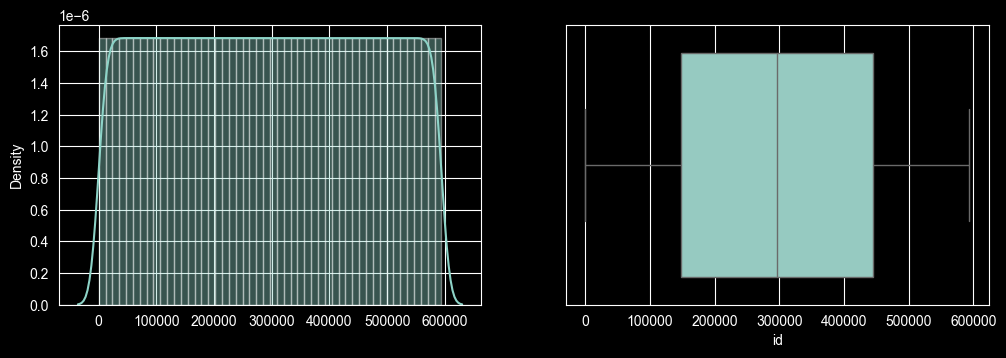

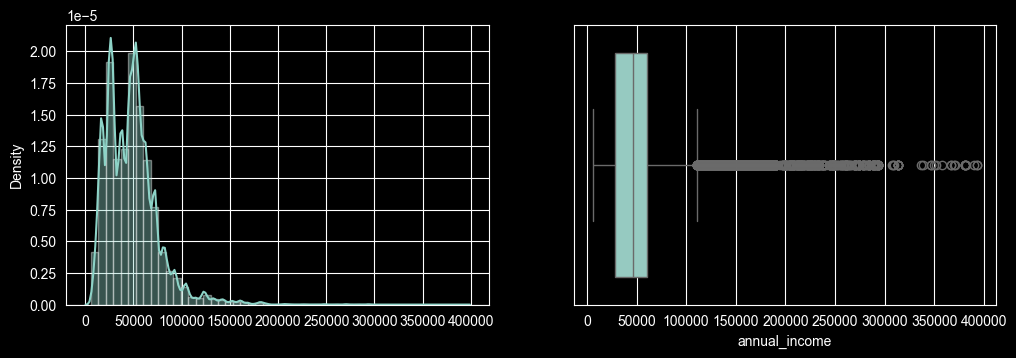

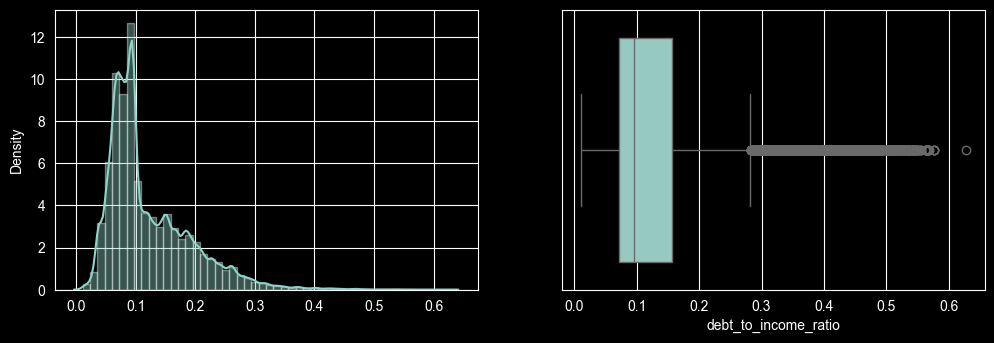

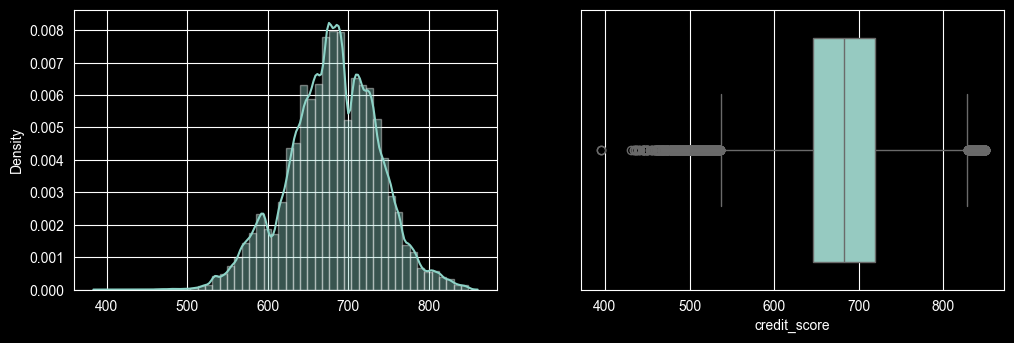

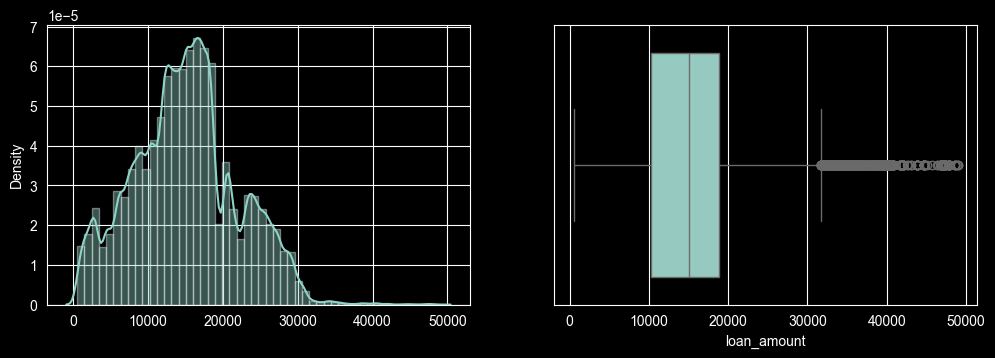

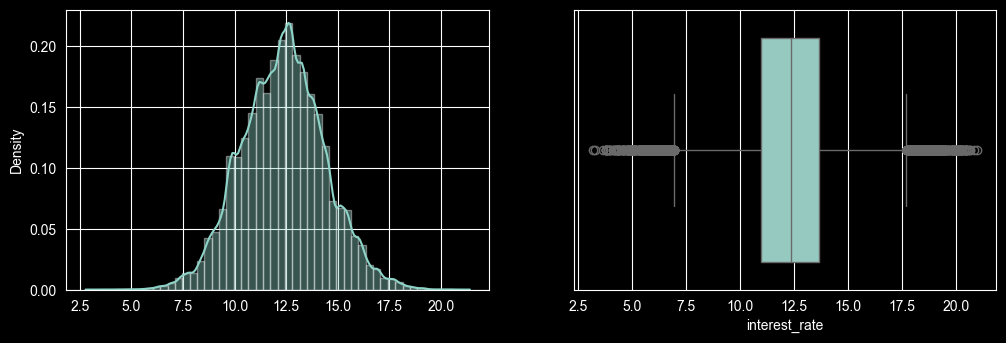

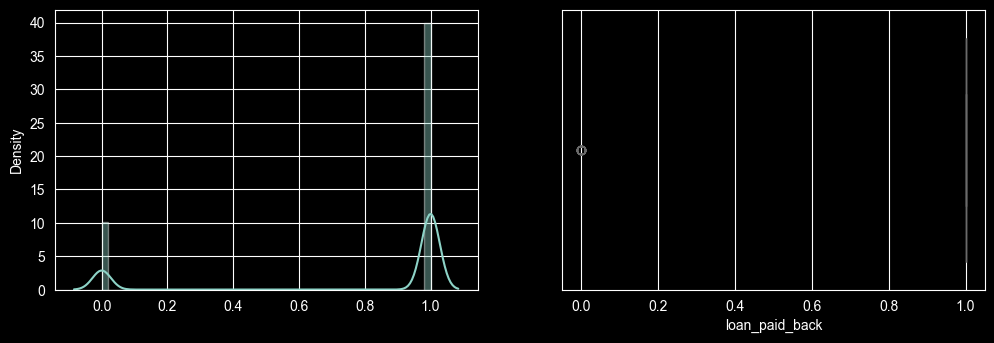

In [10]:
for col in num_cols:
    plt.figure(figsize=(12,8))
    plt.subplot(221)
    sns.distplot(x=df[col])
    plt.subplot(222)
    sns.boxplot(x=df[col])

<Axes: >

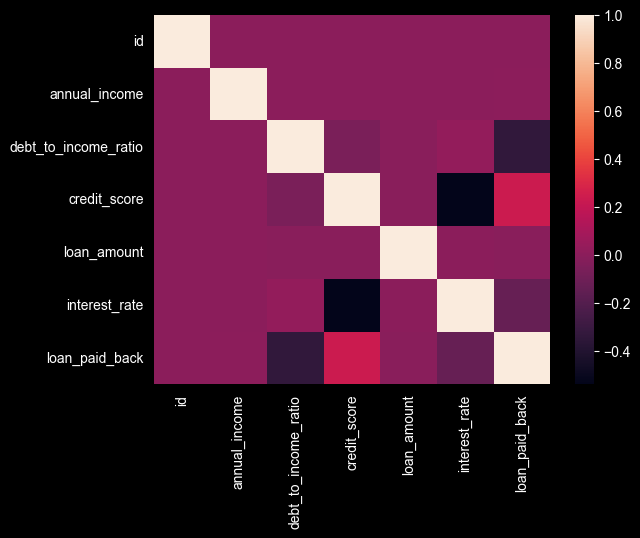

In [11]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr)

In [12]:
for col in cat_cols:
    print(df[col].value_counts())

gender
Female    306175
Male      284091
Other       3728
Name: count, dtype: int64
marital_status
Single      288843
Married     277239
Divorced     21312
Widowed       6600
Name: count, dtype: int64
education_level
Bachelor's     279606
High School    183592
Master's        93097
Other           26677
PhD             11022
Name: count, dtype: int64
employment_status
Employed         450645
Unemployed        62485
Self-employed     52480
Retired           16453
Student           11931
Name: count, dtype: int64
loan_purpose
Debt consolidation    324695
Other                  63874
Car                    58108
Home                   44118
Education              36641
Business               35303
Medical                22806
Vacation                8449
Name: count, dtype: int64
grade_subgrade
C3    58695
C4    55957
C2    54443
C1    53363
C5    53317
D1    37029
D3    36694
D4    35097
D2    34432
D5    32101
B2    15167
B1    14344
B5    13937
B3    13926
B4    13877
E4     8036
E3   

<Axes: >

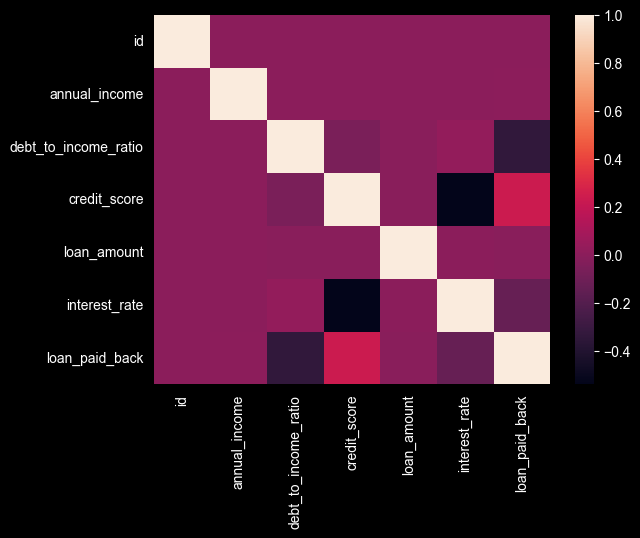

In [13]:
corr=df[num_cols].corr()
sns.heatmap(corr)

In [14]:
df[cat_cols].head()

,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,Female,Single,High School,Self-employed,Other,C3
1,Male,Married,Master's,Employed,Debt consolidation,D3
2,Male,Single,High School,Employed,Debt consolidation,C5
3,Female,Single,High School,Employed,Debt consolidation,F1
4,Male,Married,High School,Employed,Other,D1


In [15]:
df['grade']=df['grade_subgrade'].str[0]
df['subgrade']=df['grade_subgrade'].str[-1]

In [16]:
df['subgrade']=df['subgrade'].astype('int')

In [17]:
df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,grade,subgrade
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0,C,3
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0,D,3
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0,C,5
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0,F,1
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0,D,1


In [18]:
df.drop(columns=['id','grade_subgrade'],inplace=True)

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [20]:
x=df.drop(columns=['loan_paid_back'])
y=df['loan_paid_back']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [21]:
cat_cols

Index(['gender', 'marital_status', 'education_level', 'employment_status',
       'loan_purpose', 'grade_subgrade'],
      dtype='object')

In [22]:
ohe_cols=['marital_status', 'education_level', 'employment_status','loan_purpose','grade','gender']
num_cols=x_train.select_dtypes(include='number').columns

In [23]:
num_trf=('num_col',Pipeline([
    ('scale',StandardScaler())
]),num_cols)
ohe_trf=('ohe_col',Pipeline([
    ('ohe',OneHotEncoder(sparse_output=False))
]),ohe_cols)

In [24]:
transformer=ColumnTransformer(transformers=[num_trf,ohe_trf],remainder='passthrough')

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [26]:
lr=LogisticRegression()
pipe_lr=Pipeline([
    ('transformer',transformer),
    ('clf',lr)
])
pipe_lr.fit(x_train,y_train)
y_pred=pipe_lr.predict(x_test)
accuracy_score(y_test,y_pred)

0.9004789602606083

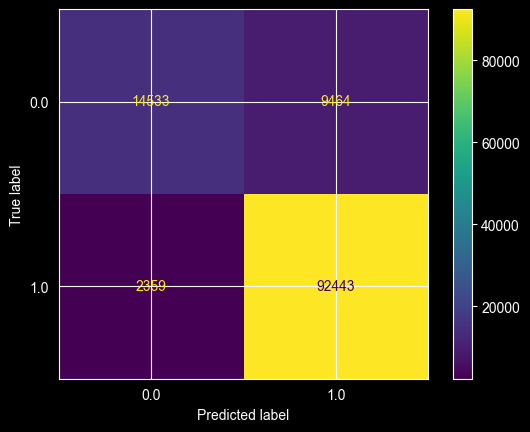

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay,classification_report

ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

In [28]:
y_pred.shape

(118799,)

In [33]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.86      0.61      0.71     23997
         1.0       0.91      0.98      0.94     94802

    accuracy                           0.90    118799
   macro avg       0.88      0.79      0.83    118799
weighted avg       0.90      0.90      0.89    118799



In [29]:
from sklearn.tree import DecisionTreeClassifier

clf=DecisionTreeClassifier()
pipe_tree=Pipeline([
    ('transformer',transformer),
    ('clf',clf)
])
pipe_tree.fit(x_train,y_train)

,steps,"[('transformer', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_col', ...), ('ohe_col', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [30]:
y_pred=pipe_tree.predict(x_test)
accuracy_score(y_test,y_pred)

0.8462865849039133

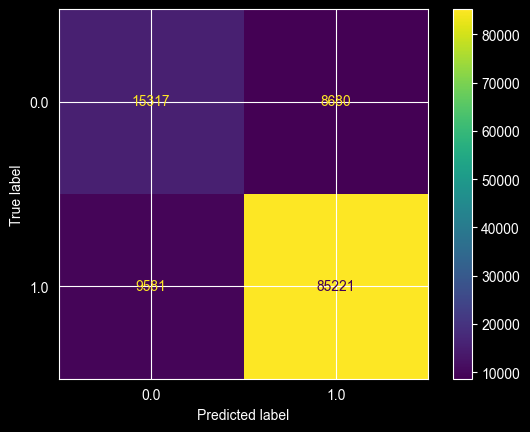

In [31]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

In [33]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.62      0.64      0.63     23997
         1.0       0.91      0.90      0.90     94802

    accuracy                           0.85    118799
   macro avg       0.76      0.77      0.76    118799
weighted avg       0.85      0.85      0.85    118799



In [26]:
rfc=RandomForestClassifier(random_state=42)
pipe_rfc=Pipeline([
    ('transformer',transformer),
    ('clf',rfc)
])
pipe_rfc.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transformer', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_col', ...), ('ohe_col', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [110]:
y_pred=pipe_rfc.predict(x_test)
accuracy_score(y_test,y_pred)

0.9013964764013165

In [111]:
xgb=XGBClassifier(random_state=42)
pipe_xgb=Pipeline([
    ('transformer',transformer),
    ('clf',xgb)
])
pipe_xgb.fit(x_train,y_train)

,steps,"[('transformer', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_col', ...), ('ohe_col', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [112]:
y_pred=pipe_xgb.predict(x_test)
accuracy_score(y_test,y_pred)

0.9047550905310651

In [115]:
test=pd.read_csv('test.csv')
test['grade']=test['grade_subgrade'].str[0]
test['subgrade']=test['grade_subgrade'].str[-1]
test['subgrade']=test['subgrade'].astype('int')
test.drop(columns=['id','grade_subgrade'],inplace=True)

In [116]:
#rfc
y_test_sub=pd.read_csv('sample_submission.csv')
test_preds = pipe_rfc.predict(test)
submission = y_test_sub.copy()
submission['loan_paid_back'] = test_preds
submission.to_csv('final_submission_rfc.csv', index=False)
print("Successfull!")

Successfull!


In [117]:
#xgb
y_test_sub=pd.read_csv('sample_submission.csv')
test_preds = pipe_xgb.predict(test)
submission = y_test_sub.copy()
submission['loan_paid_back'] = test_preds
submission.to_csv('final_submission_xgb.csv', index=False)
print("Successfull!")

Successfull!
